In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import genextreme

In [93]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

In [94]:
file_path = "../data/raw/Dados climáticos de 1984 a 2014 - Formatado.xlsx"

In [95]:
dados = pd.read_excel(file_path, sheet_name="dados")

In [96]:
dados.columns = dados.columns.str.strip()

In [97]:
dados.columns.tolist()

['Data',
 'mm/dia - Precipitação',
 'mm/dia - Evapotranspiração',
 'C° - Temperatura Média',
 'W/m² - Radiação']

In [98]:
dados["Ano"] = dados["Data"].dt.year

In [99]:
dados.head()

,Data,mm/dia - Precipitação,mm/dia - Evapotranspiração,C° - Temperatura Média,W/m² - Radiação,Ano
0,1984-01-01,0.989776,0.518743,25.419519,211.801254,1984
1,1984-01-02,0.166336,0.587044,26.399133,204.752853,1984
2,1984-01-03,0.256648,0.419522,26.202539,217.430527,1984
3,1984-01-04,0.000000,0.478503,26.720331,222.075912,1984
4,1984-01-05,0.000000,0.374592,27.286249,220.100525,1984


In [100]:
p95_radiacao = dados["W/m² - Radiação"].quantile(0.95)

p95_radiacao

np.float64(226.30423349999998)

In [101]:
dias_radiacao_extrema = dados[
    dados["W/m² - Radiação"] >= p95_radiacao
]

In [102]:
len(dias_radiacao_extrema)

567

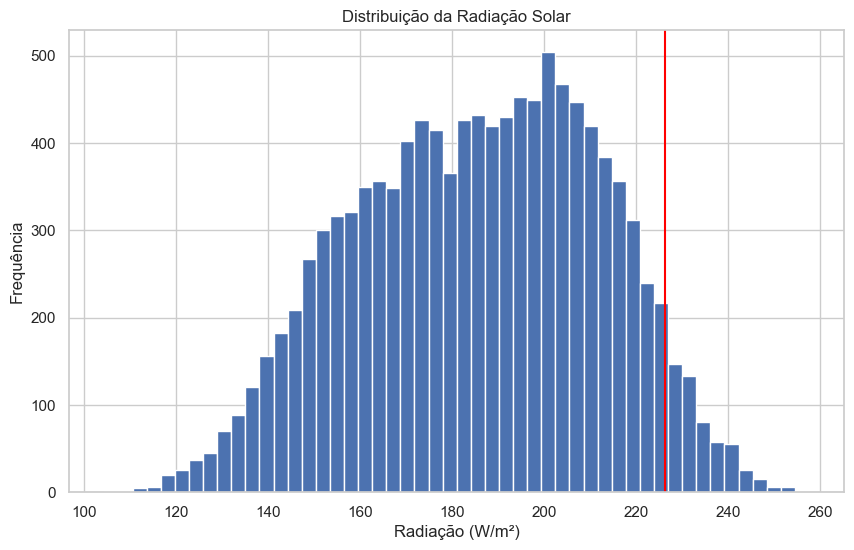

In [103]:
plt.hist(dados["W/m² - Radiação"], bins=50)

plt.axvline(p95_radiacao, color="red")

plt.title("Distribuição da Radiação Solar")
plt.xlabel("Radiação (W/m²)")
plt.ylabel("Frequência")

plt.show()

In [104]:
p95_temp = dados["C° - Temperatura Média"].quantile(0.95)

p95_temp

np.float64(27.07747340000004)

In [105]:
dias_temp_extrema = dados[
    dados["C° - Temperatura Média"] >= p95_temp
]

In [106]:
len(dias_temp_extrema)

567

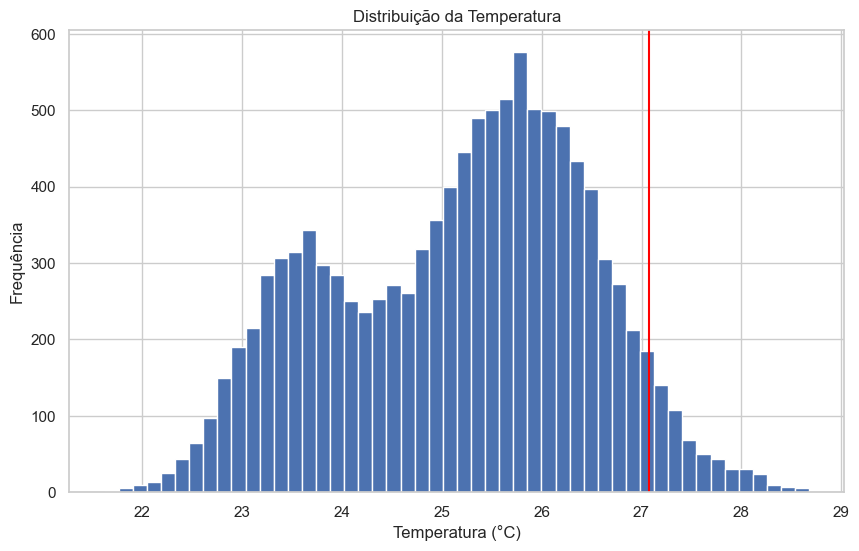

In [107]:
plt.hist(dados["C° - Temperatura Média"], bins=50)

plt.axvline(p95_temp, color="red")

plt.title("Distribuição da Temperatura")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Frequência")

plt.show()

In [108]:
dias_seca = dados[
    dados["mm/dia - Precipitação"] < 1
]

In [109]:
len(dias_seca)

6340

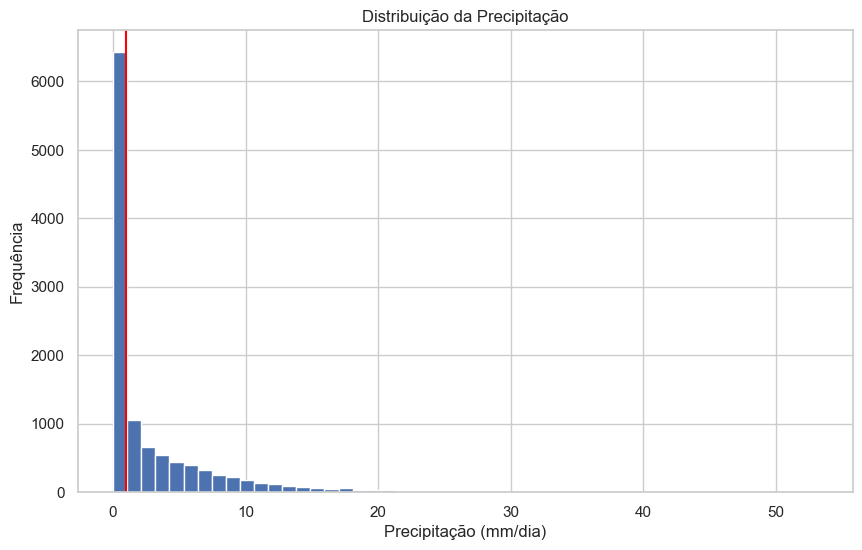

In [110]:
plt.hist(dados["mm/dia - Precipitação"], bins=50)

plt.axvline(1, color="red")

plt.title("Distribuição da Precipitação")
plt.xlabel("Precipitação (mm/dia)")
plt.ylabel("Frequência")

plt.show()

In [111]:
maximos_anuais_radiacao = dados.groupby("Ano")["W/m² - Radiação"].max()

maximos_anuais_radiacao.head()

Ano
1984    247.683044
1985    240.706070
1986    224.920944
1987    246.617401
1988    233.393799
Name: W/m² - Radiação, dtype: float64

In [112]:
params_gev = genextreme.fit(maximos_anuais_radiacao)

params_gev

(np.float64(0.40945014359293597),
 np.float64(237.02837020789406),
 np.float64(10.070631502659026))

In [113]:
x = np.linspace(
    maximos_anuais_radiacao.min(),
    maximos_anuais_radiacao.max(),
    200
)

pdf = genextreme.pdf(x, *params_gev)

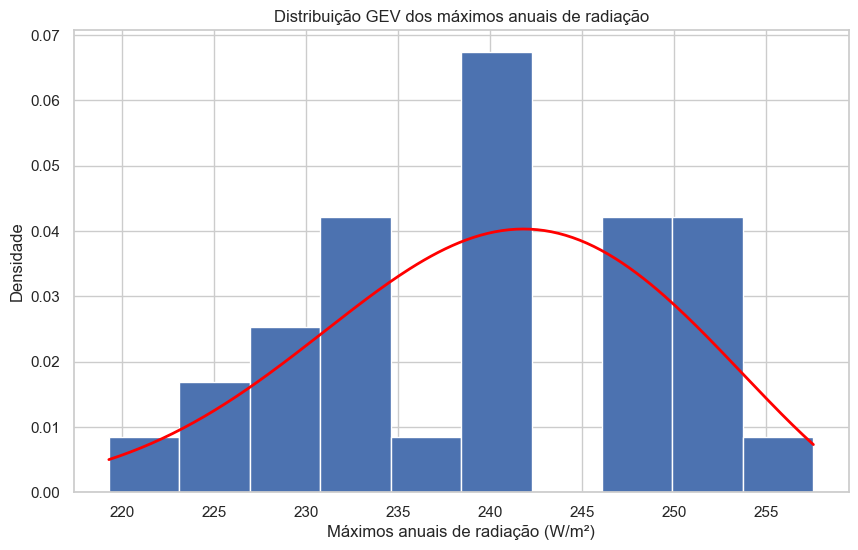

In [114]:
plt.hist(maximos_anuais_radiacao, bins=10, density=True)

plt.plot(x, pdf, color="red", linewidth=2)

plt.title("Distribuição GEV dos máximos anuais de radiação")
plt.xlabel("Máximos anuais de radiação (W/m²)")
plt.ylabel("Densidade")

plt.show()

In [115]:
resumo_extremos = pd.DataFrame({

    "Indicador": [
        "Percentil 95 Radiação",
        "Dias de radiação extrema",
        "Percentil 95 Temperatura",
        "Dias de temperatura extrema",
        "Dias secos (<1 mm)"
    ],

    "Valor": [
        p95_radiacao,
        len(dias_radiacao_extrema),
        p95_temp,
        len(dias_temp_extrema),
        len(dias_seca)
    ]

})

resumo_extremos

,Indicador,Valor
0,Percentil 95 Radiação,226.304233
1,Dias de radiação extrema,567.000000
2,Percentil 95 Temperatura,27.077473
3,Dias de temperatura extrema,567.000000
4,Dias secos (<1 mm),6340.000000


# Etapa 7 — Análise de extremos climáticos

Nesta etapa, o objetivo foi avaliar a ocorrência de **eventos climáticos extremos** relacionados à radiação solar, temperatura e precipitação. Para isso, foram utilizadas duas abordagens principais:

- **análise de percentis**, para identificar valores extremos em escala diária;
- **análise da distribuição GEV (Generalized Extreme Value)**, para modelar os máximos anuais de radiação.

A proposta da etapa foi atendida, pois foram identificados dias de radiação extrema, dias de temperatura extrema, períodos de seca, além da construção de tabelas e gráficos para interpretação dos resultados.

---

## 1. Preparação dos dados

Inicialmente, os dados foram importados, tratados e organizados para a análise. Em seguida, foi criada a variável **Ano** a partir da coluna de data.

Essa etapa foi importante porque permitiu trabalhar os dados em duas escalas:

- **escala diária**, usada na identificação de eventos extremos por percentis;
- **escala anual**, usada para extrair os máximos anuais e ajustar a distribuição GEV.

Portanto, a preparação da base foi adequada para a análise de extremos climáticos.

---

## 2. Análise dos extremos de radiação solar por percentil

Para identificar dias de radiação extrema, foi calculado o **percentil 95** da variável radiação solar.

O valor encontrado foi:

- **Percentil 95 da radiação:** 226,30 W/m²

A partir desse valor, foram selecionados todos os dias com radiação maior ou igual a esse limiar. O total encontrado foi:

- **Dias de radiação extrema:** 567 dias

### Interpretação

O percentil 95 representa o limite acima do qual estão os **5% maiores valores** de radiação da série histórica. Assim, os 567 dias identificados correspondem aos episódios de radiação solar extrema.

Esse resultado é importante porque dias com radiação elevada representam condições de maior disponibilidade energética para o aproveitamento solar.

### Interpretação do gráfico

O histograma da radiação solar mostrou a distribuição dos valores ao longo da série, enquanto a linha vermelha indicou o ponto de corte do percentil 95. Essa visualização facilitou a identificação da faixa extrema de radiação.

---

## 3. Análise dos extremos de temperatura por percentil

De forma semelhante, foi calculado o **percentil 95** da temperatura média.

O valor encontrado foi:

- **Percentil 95 da temperatura:** 27,08 °C

A partir desse limiar, foram selecionados os dias com temperatura maior ou igual a esse valor. O total obtido foi:

- **Dias de temperatura extrema:** 567 dias

### Interpretação

Esse resultado indica que 567 observações pertencem ao grupo dos **5% dias mais quentes** da série histórica.

A identificação desses eventos é relevante porque extremos de temperatura ajudam a caracterizar o comportamento climático da região e podem influenciar o desempenho ambiental associado ao aproveitamento solar.

### Interpretação do gráfico

O histograma da temperatura mostrou a distribuição dos valores e destacou, com a linha vermelha, o limiar do percentil 95. Isso permitiu visualizar claramente a região correspondente aos eventos extremos de temperatura.

---

## 4. Identificação de períodos secos

Para caracterizar condições de seca, foi adotado o critério de considerar como **dia seco** todo dia com precipitação inferior a **1 mm/dia**.

O total encontrado foi:

- **Dias secos (< 1 mm):** 6340 dias

### Interpretação

Esse resultado mostra a forte predominância de dias com precipitação muito baixa ao longo da série histórica. Em uma região semiárida, esse comportamento é esperado e reforça a característica climática de baixa disponibilidade hídrica.

É importante destacar que esse critério identifica **dias secos**, e não necessariamente secas prolongadas no sentido climatológico mais complexo. Ainda assim, trata-se de uma medida prática e adequada para a análise exploratória da série.

### Interpretação do gráfico

O histograma da precipitação revelou uma forte concentração de valores próximos de zero, com assimetria à direita. Isso significa que a maioria dos dias apresenta pouca ou nenhuma chuva, enquanto poucos eventos apresentam precipitação elevada.

---

## 5. Extração dos máximos anuais de radiação

Para aplicar a análise de extremos por GEV, foi necessário agrupar os dados por ano e extrair o **valor máximo anual da radiação solar**.

Essa etapa foi correta e necessária, pois a distribuição GEV é normalmente ajustada sobre máximos de blocos, como máximos anuais.

### Interpretação

Ao extrair os máximos anuais, a análise deixa de considerar todos os valores diários e passa a focar apenas nos **maiores eventos de radiação registrados em cada ano** da série.

Isso permite estudar o comportamento dos extremos de forma mais apropriada.

---

## 6. Ajuste da distribuição GEV aos máximos anuais

Após a extração dos máximos anuais, foi ajustada a distribuição **GEV (Generalized Extreme Value)**.

Essa distribuição é amplamente utilizada para modelar estatisticamente eventos extremos, como máximas temperaturas, chuvas intensas ou, neste caso, máximos anuais de radiação solar.

### Interpretação

O ajuste da GEV permitiu representar probabilisticamente o comportamento dos extremos anuais de radiação. Em termos práticos, isso mostra como os maiores valores anuais da série se distribuem e oferece uma base mais robusta para a análise estatística dos extremos.

### Interpretação do gráfico

No gráfico, o histograma dos máximos anuais foi comparado à curva ajustada da GEV. O ajuste visual foi coerente, embora seja importante considerar que o número de anos disponíveis é relativamente pequeno, o que limita análises mais robustas. Ainda assim, como análise exploratória e aplicada, o procedimento foi adequado.

---

## 7. Tabela-resumo dos extremos climáticos

Ao final da etapa, foi construída uma tabela-resumo com os principais indicadores obtidos:

| Indicador | Valor |
|---|---:|
| Percentil 95 da radiação | 226,30 |
| Dias de radiação extrema | 567 |
| Percentil 95 da temperatura | 27,08 |
| Dias de temperatura extrema | 567 |
| Dias secos (< 1 mm) | 6340 |

### Interpretação

Essa tabela sintetiza os principais resultados da análise de extremos climáticos. Ela mostra que a série histórica apresenta:

- ocorrência bem definida de eventos extremos de radiação;
- ocorrência bem definida de eventos extremos de temperatura;
- predominância de dias secos, característica típica de clima semiárido.

---

## 8. Conclusão da etapa

A análise de extremos climáticos foi conduzida de forma coerente com o que foi solicitado. A utilização dos **percentis** permitiu identificar dias de radiação extrema e temperatura extrema, enquanto a definição de dias secos possibilitou caracterizar a baixa pluviosidade da série. Além disso, o ajuste da **distribuição GEV** aos máximos anuais de radiação forneceu uma abordagem estatística adequada para a avaliação dos extremos anuais.

De forma geral, os resultados mostram que a região apresenta:

- eventos relevantes de alta radiação solar;
- episódios de temperatura elevada;
- forte predominância de dias secos;
- comportamento compatível com um clima favorável ao aproveitamento solar, especialmente sob a ótica da disponibilidade de radiação e da baixa frequência de chuva.
